# Healthcare — Diabetes Prediction: Modeling

Train multiple models on the **80%** train split, tune/select on the **10%** validation split,
and report final performance on the untouched **10%** test split.

Preprocessing (identical to notebook 01) is imported from `src/preprocessing.py` so training
and the future live demo share one code path. All transforms are fit on **train only**.

**Metric focus:** the target is imbalanced (~8.8% positive), so we rank models by **PR-AUC**
(average precision) and **recall**, not accuracy.

> **Note:** XGBoost requires the `libomp` system library (Homebrew). To keep the stack
> dependency-light and free-tier friendly, we use scikit-learn's `HistGradientBoosting`
> (a strong gradient-boosting alternative) instead.

In [1]:
import sys, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath("../src"))
from preprocessing import load_splits

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_score, recall_score, accuracy_score,
                             classification_report, confusion_matrix,
                             precision_recall_curve, roc_curve)

RANDOM_STATE = 42
DATA_PATH = "../../data/healthcare-diabetes/diabetes_prediction_dataset.csv"


## 1. Load the 80/10/10 splits (transformed, fit on train only)

In [2]:
d = load_splits(DATA_PATH, transform=True)
Xtr, Xval, Xte = d["X_train_t"], d["X_val_t"], d["X_test_t"]
ytr, yval, yte = d["y_train"].values, d["y_val"].values, d["y_test"].values
feat_names = d["feature_names"]

print("train:", Xtr.shape, "| val:", Xval.shape, "| test:", Xte.shape)
print("positives -> train %.2f%%  val %.2f%%  test %.2f%%" % (ytr.mean()*100, yval.mean()*100, yte.mean()*100))
print("n_features:", len(feat_names))

# imbalance ratio for boosting sample weights
pos_weight = (ytr == 0).sum() / (ytr == 1).sum()
print("neg/pos ratio (train):", round(pos_weight, 2))


train: (76916, 29) | val: (9615, 29) | test: (9615, 29)
positives -> train 8.82%  val 8.82%  test 8.82%
n_features: 29
neg/pos ratio (train): 10.33


## 2. Define models (all with class-imbalance handling)

In [3]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced",
                                             random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                           n_jobs=-1, random_state=RANDOM_STATE),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=300, learning_rate=0.08,
                                                           random_state=RANDOM_STATE),
}
# HGB has no class_weight -> use sample_weight to upweight the minority class
sw = np.where(ytr == 1, pos_weight, 1.0)


## 3. Train on 80%, evaluate on validation 10%

In [4]:
def eval_scores(y_true, proba, thr=0.5):
    pred = (proba >= thr).astype(int)
    return {
        "ROC_AUC": roc_auc_score(y_true, proba),
        "PR_AUC": average_precision_score(y_true, proba),
        "F1": f1_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred),
        "Accuracy": accuracy_score(y_true, pred),
    }

val_rows, fitted = [], {}
for name, mdl in models.items():
    if name == "HistGradientBoosting":
        mdl.fit(Xtr, ytr, sample_weight=sw)
    else:
        mdl.fit(Xtr, ytr)
    fitted[name] = mdl
    proba_val = mdl.predict_proba(Xval)[:, 1]
    val_rows.append({"model": name, **eval_scores(yval, proba_val)})

val_df = pd.DataFrame(val_rows).set_index("model").round(4)
val_df.sort_values("PR_AUC", ascending=False)


/Users/khizar.sultan/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/khizar.sultan/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/khizar.sultan/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/khizar.sultan/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/khizar.sultan/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_fea

,ROC_AUC,PR_AUC,F1,Precision,Recall,Accuracy
model,,,,,,
HistGradientBoosting,0.9803,0.8974,0.6332,0.4824,0.9210,0.9059
RandomForest,0.9689,0.8761,0.8119,0.9568,0.7052,0.9712
LogisticRegression,0.9698,0.8521,0.5754,0.4209,0.9092,0.8816


## 4. Select best model (by validation PR-AUC) + tune decision threshold on val

In [5]:
best_name = val_df["PR_AUC"].idxmax()
best_model = fitted[best_name]
print("Best model by val PR-AUC:", best_name)

# choose threshold that maximizes F1 on the validation set
proba_val = best_model.predict_proba(Xval)[:, 1]
prec, rec, thrs = precision_recall_curve(yval, proba_val)
f1s = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = np.nanargmax(f1s[:-1])          # last point has no threshold
best_thr = float(thrs[best_idx])
print("Tuned threshold (max F1 on val): %.3f  -> val F1=%.4f" % (best_thr, f1s[best_idx]))


Best model by val PR-AUC: HistGradientBoosting
Tuned threshold (max F1 on val): 0.865  -> val F1=0.8347


## 5. Final evaluation on the untouched test 10%

In [6]:
proba_te = best_model.predict_proba(Xte)[:, 1]
default_scores = eval_scores(yte, proba_te, thr=0.5)
tuned_scores   = eval_scores(yte, proba_te, thr=best_thr)

final = pd.DataFrame({"threshold=0.50": default_scores,
                      f"threshold={best_thr:.3f}": tuned_scores}).round(4)
print("Final TEST performance —", best_name)
final


Final TEST performance — HistGradientBoosting


,threshold=0.50,threshold=0.865
ROC_AUC,0.9735,0.9735
PR_AUC,0.8653,0.8653
F1,0.6108,0.7964
Precision,0.4651,0.9601
Recall,0.8892,0.6804
Accuracy,0.9001,0.9693


In [7]:
pred_te = (proba_te >= best_thr).astype(int)
print("Classification report (tuned threshold) on TEST:\n")
print(classification_report(yte, pred_te, target_names=["no_diabetes","diabetes"], digits=4))


Classification report (tuned threshold) on TEST:

              precision    recall  f1-score   support

 no_diabetes     0.9699    0.9973    0.9834      8767
    diabetes     0.9601    0.6804    0.7964       848

    accuracy                         0.9693      9615
   macro avg     0.9650    0.8388    0.8899      9615
weighted avg     0.9691    0.9693    0.9669      9615



## 6. Diagnostic plots (test set)

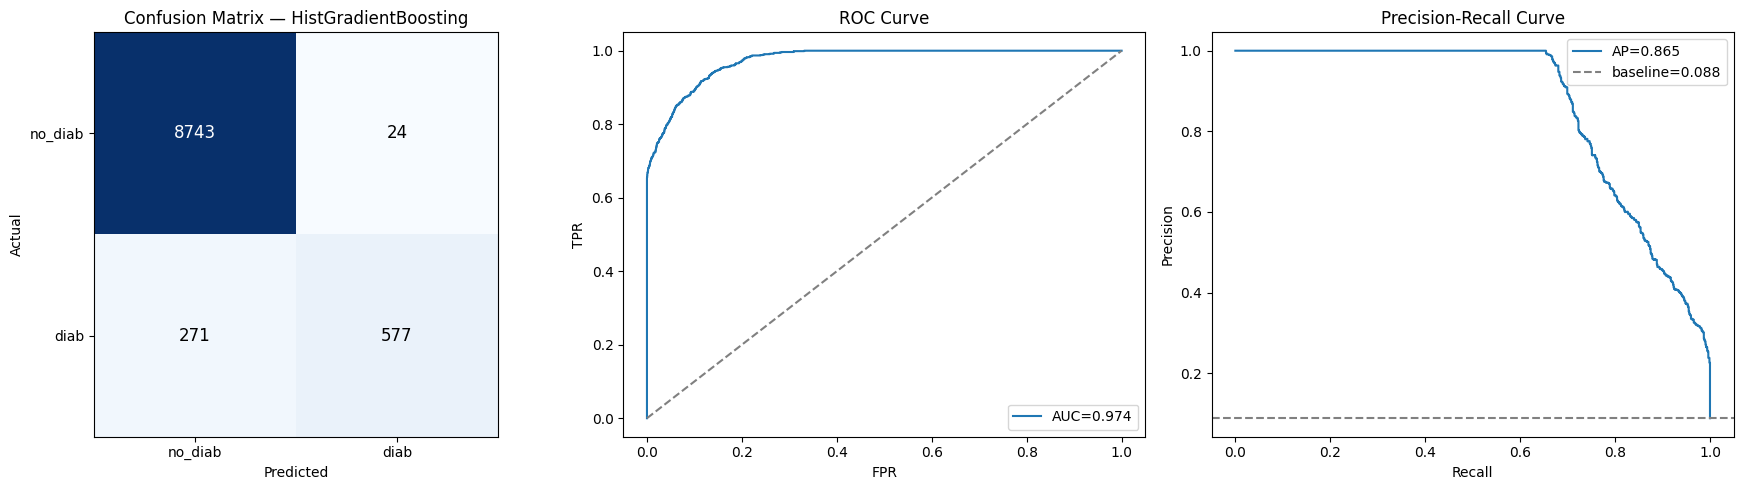

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm = confusion_matrix(yte, pred_te)
im = ax[0].imshow(cm, cmap="Blues")
ax[0].set_title(f"Confusion Matrix — {best_name}")
ax[0].set_xticks([0,1]); ax[0].set_xticklabels(["no_diab","diab"])
ax[0].set_yticks([0,1]); ax[0].set_yticklabels(["no_diab","diab"])
ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("Actual")
for (i,j),v in np.ndenumerate(cm):
    ax[0].text(j, i, str(v), ha="center", va="center",
               color="white" if v>cm.max()/2 else "black", fontsize=12)

# ROC curve
fpr, tpr, _ = roc_curve(yte, proba_te)
ax[1].plot(fpr, tpr, label="AUC=%.3f" % roc_auc_score(yte, proba_te))
ax[1].plot([0,1],[0,1],"--",color="grey")
ax[1].set_title("ROC Curve"); ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR"); ax[1].legend()

# PR curve
p, r, _ = precision_recall_curve(yte, proba_te)
ax[2].plot(r, p, label="AP=%.3f" % average_precision_score(yte, proba_te))
ax[2].axhline(yte.mean(), ls="--", color="grey", label="baseline=%.3f" % yte.mean())
ax[2].set_title("Precision-Recall Curve"); ax[2].set_xlabel("Recall"); ax[2].set_ylabel("Precision"); ax[2].legend()
plt.tight_layout(); plt.show()


## 7. Feature importance / drivers

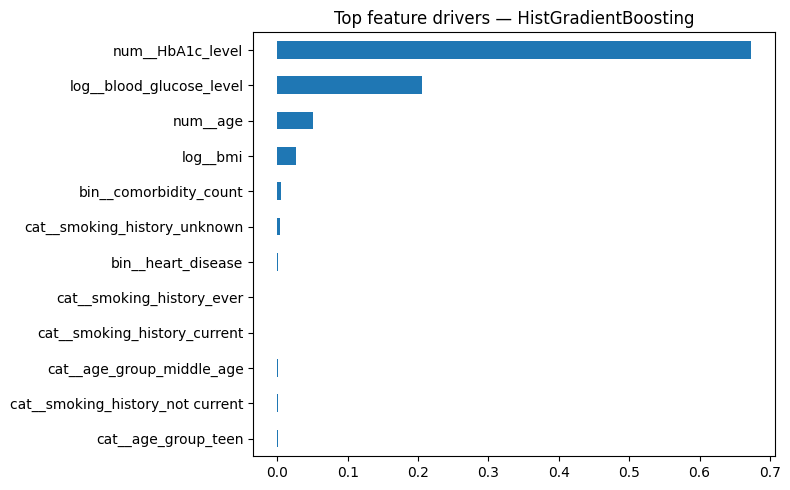

num__HbA1c_level                    0.6732
log__blood_glucose_level            0.2052
num__age                            0.0501
log__bmi                            0.0270
bin__comorbidity_count              0.0050
cat__smoking_history_unknown        0.0032
bin__heart_disease                  0.0008
cat__smoking_history_ever          -0.0006
cat__smoking_history_current       -0.0005
cat__age_group_middle_age           0.0005
cat__smoking_history_not current    0.0004
cat__age_group_teen                 0.0003
dtype: float64

In [9]:
if best_name == "LogisticRegression":
    imp = pd.Series(best_model.coef_[0], index=feat_names)
elif best_name == "RandomForest":
    imp = pd.Series(best_model.feature_importances_, index=feat_names)
else:
    # HistGradientBoosting: permutation importance (on a val subsample for speed)
    from sklearn.inspection import permutation_importance
    r = permutation_importance(best_model, Xval, yval, n_repeats=5,
                               random_state=RANDOM_STATE, scoring="average_precision")
    imp = pd.Series(r.importances_mean, index=feat_names)

top = imp.reindex(imp.abs().sort_values(ascending=False).index).head(12)
plt.figure(figsize=(8,5))
top[::-1].plot(kind="barh")
plt.title(f"Top feature drivers — {best_name}"); plt.tight_layout(); plt.show()
top.round(4)


## 8. Persist the winning model + preprocessor (for the live demo)

In [10]:
import joblib
os.makedirs("../models", exist_ok=True)
artifact = {
    "model": best_model,
    "preprocessor": d["preprocessor"],
    "threshold": best_thr,
    "feature_names": list(feat_names),
    "model_name": best_name,
}
joblib.dump(artifact, "../models/diabetes_model.joblib")
print("Saved -> ../models/diabetes_model.joblib")
print("Model:", best_name, "| tuned threshold:", round(best_thr,3))


Saved -> ../models/diabetes_model.joblib
Model: HistGradientBoosting | tuned threshold: 0.865


## 9. Summary

- Trained **3 models** (Logistic Regression, Random Forest, HistGradientBoosting), all with
  class-imbalance handling, on the **80%** split.
- Selected the best by **validation PR-AUC**, then tuned the decision threshold for F1 on validation.
- Reported final metrics on the untouched **10% test** set (ROC-AUC, PR-AUC, precision, recall, F1)
  plus confusion matrix, ROC/PR curves, and feature drivers.
- Saved `{model, preprocessor, threshold}` to `models/diabetes_model.joblib` for the live Gradio demo.